> Univariate Imputatn is applicable on both Numerical and Categorical Data

# Handling Missing Numerical Data
> 1. UNivariate Imputatn
- When filling missing val in a col with other val of the same col in which missing val is present
- Filling missing val using Statistical vals

> 2. Multivariate Imputatn
- Filling missing vals using vals of same or different cols

# Univariate Imputatn
1. Using Mean / Median
2. Using One Arbitrary val
3. Using End of Distribtn
4. Using Random vals
5. Using Missing Indicator
6. Autmatically Select Val For Imputation


> <h3>1. Mean/Median</h3>
- Mean -> Use when Distn is Normal
- Median -> Use when Distn is Skewed
- BENEFITS : Simple to implement
- DISADVANTAGE : Change Distribtn Shape, Create Outliers, Change Covariance/Corr
- When TO use : MCAR, Val %age < 5%

- Two ways To implement : Sklearn, fillna(pd)

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
df = pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\python\pyCourse\csvFiles\titanic_toy.csv')

In [41]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [42]:
df.isnull().mean()*100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [43]:
x = df.iloc[:,0:3]
y = df.iloc[:,-1]

In [44]:
from sklearn.model_selection import train_test_split
x_tr, x_ts, y_tr, y_ts = train_test_split(x,y, test_size=0.2, random_state=42)

> <h4>a. Using fillna</h4>
1. Find mean of cols in which missing val is present
2. Make new col and fill them with mean data using fillna()

In [45]:
mean_age = x_tr['Age'].mean()
mean_fare = x_tr['Fare'].mean()

median_age = x_tr['Age'].median()
median_fare = x_tr['Fare'].median()

In [46]:
x_tr['Age_median'] = x_tr['Age'].fillna(median_age)
x_tr['Age_mean'] = x_tr['Age'].fillna(mean_age)

x_tr['Fare_median'] = x_tr['Fare'].fillna(median_fare)
x_tr['Fare_mean'] = x_tr['Fare'].fillna(mean_fare)

In [47]:
x_tr.sample(5)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
884,25.0,7.0500,0,25.0,25.000000,7.0500,7.0500
627,21.0,77.9583,0,21.0,21.000000,77.9583,77.9583
437,24.0,18.7500,5,24.0,24.000000,18.7500,18.7500
593,NaN,7.7500,2,28.0,29.498846,7.7500,7.7500
557,NaN,227.5250,0,28.0,29.498846,227.5250,227.5250


> <h5>For checking Mean/Median Imputn accuracy</h5>
1. Checking for Variance behaviour
- Whenever we apply Mean/Median imputn, the Variance will shrink But Not TOO Much
2. PLot the distrbtn for finding change in distribtn
3. Check the Covariance
4. Plot the Boxplot for Outliers change

In [48]:
print('Original Age var Variance: ', x_tr['Age'].var())
print('Age Variance after Mean imputn: ', x_tr['Age_mean'].var())
print('Age var Variance after Median imputn: ', x_tr['Age_median'].var())

print('Original Fare var Variance: ', x_tr['Fare'].var())
print('Fare var Variance after Mean imputn: ', x_tr['Fare_mean'].var())
print('Fare var Variance after Median imputn: ', x_tr['Fare_median'].var())

Original Age var Variance:  210.2517072477435
Age Variance after Mean imputn:  168.85193366872227
Age var Variance after Median imputn:  169.20731007048155
Original Fare var Variance:  2761.0314349486343
Fare var Variance after Mean imputn:  2621.232374951235
Fare var Variance after Median imputn:  2637.012481677765


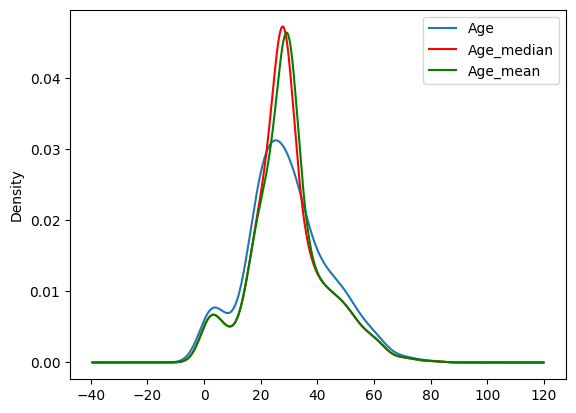

In [49]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original var disbtn
x_tr['Age'].plot(kind='kde', ax=ax)
# var imputed with median
x_tr['Age_median'].plot(kind='kde', ax=ax, color='red')
# var imputed with mean
x_tr['Age_mean'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

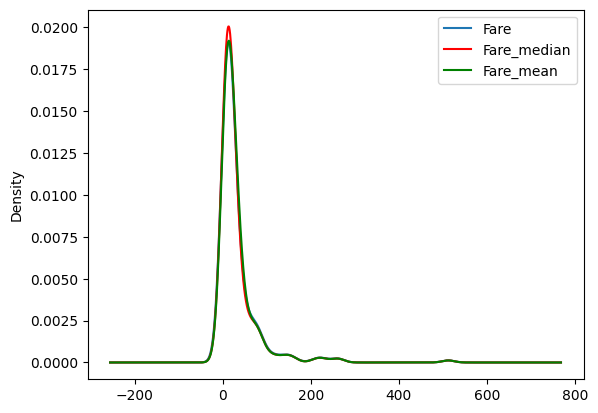

In [50]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original var disbtn
x_tr['Fare'].plot(kind='kde', ax=ax)
# var imputed with median
x_tr['Fare_median'].plot(kind='kde', ax=ax, color='red')
# var imputed with mean
x_tr['Fare_mean'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

In [51]:
# Checking covariance(relation with other cols, does not lies b/w 0&1)
x_tr.cov()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,210.251707,75.481375,-6.993325,210.251707,210.251707,70.082085,71.193767
Fare,75.481375,2761.031435,18.599163,63.938058,60.224654,2761.031435,2761.031435
Family,-6.993325,18.599163,2.830892,-5.587710,-5.616299,17.672035,17.657433
Age_median,210.251707,63.938058,-5.587710,169.207310,168.851934,59.728510,60.700688
Age_mean,210.251707,60.224654,-5.616299,168.851934,168.851934,56.282518,57.175304
Fare_median,70.082085,2761.031435,17.672035,59.728510,56.282518,2637.012482,2621.232375
Fare_mean,71.193767,2761.031435,17.657433,60.700688,57.175304,2621.232375,2621.232375


In [52]:
# lies b/w 0 & 1
x_tr.corr()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,1.000000,0.091482,-0.319651,1.000000,1.000000,0.087232,0.088944
Fare,0.091482,1.000000,0.207193,0.093496,0.088151,1.000000,1.000000
Family,-0.319651,0.207193,1.000000,-0.255307,-0.256883,0.204536,0.204981
Age_median,1.000000,0.093496,-0.255307,1.000000,0.998949,0.089416,0.091145
Age_mean,1.000000,0.088151,-0.256883,0.998949,1.000000,0.084346,0.085941
Fare_median,0.087232,1.000000,0.204536,0.089416,0.084346,1.000000,0.997003
Fare_mean,0.088944,1.000000,0.204981,0.091145,0.085941,0.997003,1.000000


<Axes: >

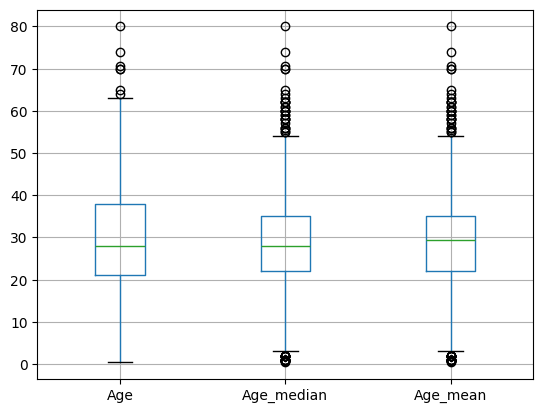

In [53]:
x_tr[['Age','Age_median','Age_mean']].boxplot()

<Axes: >

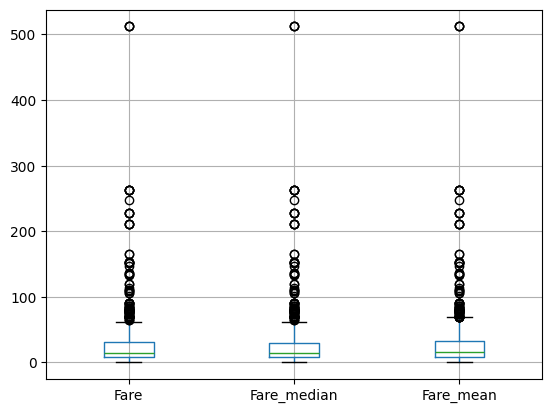

In [54]:
x_tr[['Fare','Fare_median','Fare_mean']].boxplot()

> Conclusion :
- We can use Mean/Median imputatn for "Fare" col
- But we can't use it on "Age" cols as it makes additional outliers & change distribtn shape

<h4>b. Using Sklearn</h4>

In [55]:
x_tr, x_ts, y_tr, y_ts = train_test_split(x,y,test_size=0.2, random_state=2)

In [56]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

In [57]:
trf = ColumnTransformer([
    ('imputer1', imputer1,[0]),
    ('imputer2', imputer2,[1])
], remainder='passthrough')

In [58]:
trf.fit(x_tr)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer1', ...), ('imputer2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featu

In [59]:
trf.named_transformers_['imputer1'].statistics_

array([28.75])

In [60]:
trf.named_transformers_['imputer2'].statistics_

array([32.61759689])

In [61]:
x_tr = trf.transform(x_tr)
x_ts = trf.transform(x_ts)

In [62]:
x_tr

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 28.75  , 221.7792,   0.    ],
       [ 28.75  ,  25.925 ,   0.    ]], shape=(712, 3))

> <h3>2. Arbitrary Val</h3>
- Categorical -> NA -> fill with -> 'Missing' word
- Numerical -> NA -> fill with -> 0,-1,99.99,etc
- Benefits : Easy to apply
- DisAdvatage : Changes PDF Distn, Variance, Covar, Corr
- When To Use : When Data is Not Missing At Random

Example -

a. Using fillna
- x_tr['Age_99'] = x_tr['Age'].fillna(99)
- x_tr['Age_minus1'] = x_tr['Age'].fillna(-1)

b. Using sklearn
- SimpleImputer(strategy='constant', fill_value=99)

> <h3>3. End of Distribtn</h3>
- It is similar to arbitrary imputing but Here we replace missing val with Extreme val of dist. not Random val
- If Normal dist -> Replace with (mean +/- 3~)
- If Skewed -> Replace using IQR proximity : (Q1 +/- 1.5IQR), IQR(Q3-Q1)
- Benefits : Easy to apply
- DisAdvatage : Changes PDF Distn, Variance, Covar, Corr
- When To Use : When Data is Not Missing At Random

> <h3>4. Random Values</h3>
1. Filling Missing Vals with Random Vals taken from Same COls in which missing val present.

2. <p>Benefits :</p> 
- Simple
- Preserves Variance of Var as FIlled with Random Vals which Occur most of the time in data
- CHange COvaraince
- Well suited for linear models as it does not distort the Distrbtn regardless of % of NA 
3. When To Use : When applying Linear algo's on data, Not useful for Decision tree
4. DisAdvantage : Memory Heavy for Deployment as we need to store the original training set to extract vals from and replace the NA in coming observatns
5. USED FOR : Both Numerical and Categorical Vals

> For Numerical Vals

In [63]:
titanic = pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\python\pyCourse\csvFiles\titanic\train.csv', usecols=['Age','Fare','Survived'])

In [64]:
titanic.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [65]:
titanic.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [130]:
u = titanic.iloc[:,1:3]
v = titanic.iloc[:,0]

In [131]:
u_tr, u_ts, v_tr, v_ts = train_test_split(u,v,test_size=0.2,random_state=2)

In [ ]:
# Making the copy of original var for comparison
u_tr['Age_imp'] = u_tr['Age']
u_ts['Age_imp'] = u_ts['Age']

In [69]:
# Getting those val of Age col which are NA and droping them and then filling it with Random Val generated from that cols
# u_tr['Age_imp'][u_tr['Age_imp'].isnull()]  -> getting missing val from age imp cols
# u_tr['Age'].dropna -> droping missing vals from age cols
# .sample(u_tr['Age'].isnull().sum()).values -> Means assign random vals generated from that cols to NA vals
u_tr['Age_imp'][u_tr['Age_imp'].isnull()]  = u_tr['Age'].dropna().sample(u_tr['Age'].isnull().sum()).values
u_ts['Age_imp'][u_ts['Age_imp'].isnull()] = u_ts['Age'].dropna().sample(u_ts['Age'].isnull().sum()).values

In [70]:
u_tr

,Age,Fare,Age_imp
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,43.0
493,71.0,49.5042,71.0
527,NaN,221.7792,4.0


> Now analysing Distbtn after Random Imputatn:
- Check for dist plot
- Check for Variance change
- Check for COVariance change
- Check for Outliers change

C:\Users\HP\AppData\Local\Temp\ipykernel_9968\196447977.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(u_tr['Age'], label='Original', hist=False)
C:\Users\HP\AppData\Local\Temp\ipykernel_9968\196447977.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(u_tr['Age_imp'], la

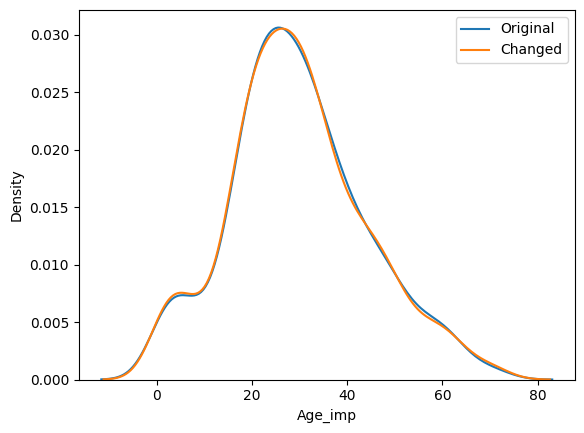

In [71]:
sns.distplot(u_tr['Age'], label='Original', hist=False)
sns.distplot(u_tr['Age_imp'], label='Changed', hist=False)

plt.legend()
plt.show()

In [72]:
print('Original Variance: ', u_tr['Age'].var())
print('Changed Variance: ', u_tr['Age_imp'].var())

Original Variance:  204.34951339046142
Changed Variance:  207.1598688095577


In [73]:
u_tr[['Fare','Age','Age_imp']].cov()

,Fare,Age,Age_imp
Fare,2368.246832,71.512440,52.844803
Age,71.512440,204.349513,204.349513
Age_imp,52.844803,204.349513,207.159869


<Axes: >

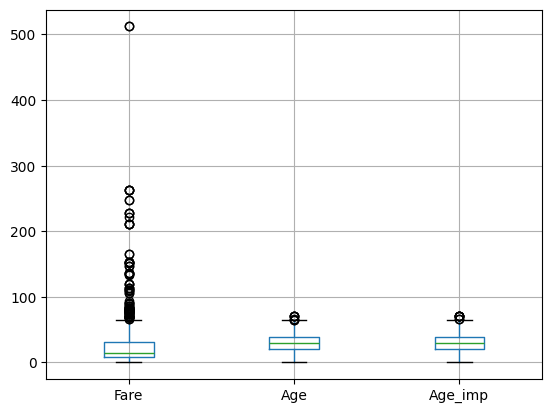

In [74]:
u_tr[['Fare','Age','Age_imp']].boxplot()

- Generating same random val for same input as it does matter when deployed
- If we don't do that, random val is generated for same input by user

In [75]:
# sample_val = u_tr['Age'].dropna().sample(1, random_state=int(observation['Fare']))

> For Categorical Data
- Same Process for Categorical Vals

In [76]:
cat = pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\python\pyCourse\csvFiles\house-train.csv', usecols=['GarageQual','FireplaceQu','SalePrice'])

In [77]:
cat.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [78]:
c = cat
d = cat['SalePrice']

In [79]:
c_tr, c_ts, d_tr, d_ts = train_test_split(c,d, test_size=0.2,random_state=2)

In [80]:
c_tr['FireplaceQu_imp'] = c_tr['FireplaceQu']
c_ts['FireplaceQu_imp'] = c_ts['FireplaceQu']

c_tr['GarageQual_imp'] = c_tr['GarageQual']
c_ts['GarageQual_imp'] = c_ts['GarageQual']

In [81]:
c_tr.sample(5)

,FireplaceQu,GarageQual,SalePrice,FireplaceQu_imp,GarageQual_imp
1033,NaN,TA,230000,NaN,TA
1253,Gd,TA,294000,Gd,TA
632,TA,TA,82500,TA,TA
294,Gd,TA,167000,Gd,TA
1152,Gd,TA,230000,Gd,TA


In [82]:
c_tr['FireplaceQu_imp'][c_tr['FireplaceQu_imp'].isnull()] = c_tr['FireplaceQu'].dropna().sample(c_tr['FireplaceQu'].isnull().sum()).values
c_ts['FireplaceQu_imp'][c_ts['FireplaceQu_imp'].isnull()] = c_ts['FireplaceQu'].dropna().sample(c_ts['FireplaceQu'].isnull().sum()).values
c_tr['GarageQual_imp'][c_tr['GarageQual_imp'].isnull()] = c_tr['GarageQual'].dropna().sample(c_tr['GarageQual'].isnull().sum()).values
c_ts['GarageQual_imp'][c_ts['GarageQual_imp'].isnull()] = c_ts['GarageQual'].dropna().sample(c_ts['GarageQual'].isnull().sum()).values

C:\Users\HP\AppData\Local\Temp\ipykernel_9968\1843838729.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_tr['FireplaceQu_imp'][c_tr['FireplaceQu_imp'].isnull()] = c_tr['FireplaceQu'].dropna().sample(c_tr['FireplaceQu'].isnull().sum()).values
C:\Users\HP\AppData\Local\Temp\ipykernel_9968\1843838729.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_ts['FireplaceQu_imp'][c_ts['FireplaceQu_imp'].isnull()] = c_ts['FireplaceQu'].dropna().sample(c_ts['FireplaceQu'].isnull().sum()).values
C:\Users\HP\AppData\Local\Temp\ipykernel_9968\1843838729.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

In [83]:
# Checking frequency of categories present in Both cols Before & After
tem = pd.concat(
    [
        c_tr['GarageQual'].value_counts() / len(c_tr['GarageQual'].dropna()),
        c_tr['GarageQual_imp'].value_counts() / len(c_tr)
    ],
    axis=1)
tem.columns = ['Original','Imputed']

In [84]:
tem

,Original,Imputed
TA,0.951043,0.951199
Fa,0.037171,0.035959
Gd,0.009973,0.011130
Po,0.000907,0.000856
Ex,0.000907,0.000856


- There is no or little change in freq of this cols, So we use this technique here

In [85]:
tem = pd.concat(
    [
        c_tr['FireplaceQu'].value_counts() / len(c_tr['FireplaceQu'].dropna()),
        c_tr['FireplaceQu_imp'].value_counts() / len(cat)
    ],
    axis=1)
tem.columns = ['Original','Imputed']
tem

,Original,Imputed
Gd,0.494272,0.396575
TA,0.412439,0.328767
Fa,0.040917,0.033562
Po,0.027823,0.021233
Ex,0.024550,0.019863


- Here freq of categories changes  very much, so it's not good apply

C:\Users\HP\AppData\Local\Temp\ipykernel_9968\1702818708.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(c_tr[c_tr['FireplaceQu'] == category]['SalePrice'], label=category, hist=False)
C:\Users\HP\AppData\Local\Temp\ipykernel_9968\1702818708.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5

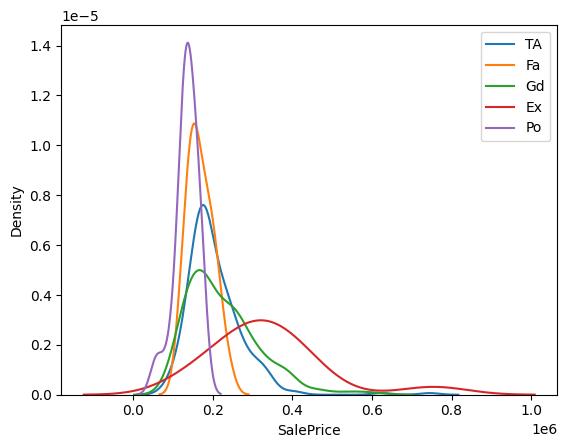

In [86]:
for category in c_tr['FireplaceQu'].dropna().unique():
    sns.distplot(c_tr[c_tr['FireplaceQu'] == category]['SalePrice'], label=category, hist=False)
plt.legend()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_9968\1893660084.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(c_tr[c_tr['FireplaceQu_imp'] == category]['SalePrice'], label=category, hist=False)
C:\Users\HP\AppData\Local\Temp\ipykernel_9968\1893660084.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750

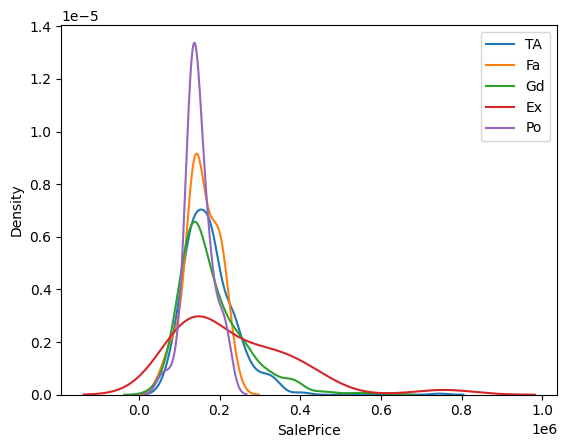

In [87]:
for category in c_tr['FireplaceQu_imp'].dropna().unique():
    sns.distplot(c_tr[c_tr['FireplaceQu_imp'] == category]['SalePrice'], label=category, hist=False)
plt.legend()
plt.show()

> <h3>5. Missing Indicator</h3>
- In this we form a New Col which contanis Boolean val where If val Present,it marks True ans If not, it marks False
- It helps model in identifying missing rows

In [110]:
from sklearn.impute import MissingIndicator

In [112]:
u_tr.head()

,Age,Fare,Age_imp
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0


> Accuracy without using Missing Indicator

In [113]:
si = SimpleImputer()
u_tr_trf = si.fit_transform(u_tr)
u_ts_trf = si.transform(u_ts)

In [114]:
u_tr_trf

array([[ 40.        ,  27.7208    ,  40.        ],
       [  4.        ,  16.7       ,   4.        ],
       [ 47.        ,   9.        ,  47.        ],
       ...,
       [ 71.        ,  49.5042    ,  71.        ],
       [ 29.78590426, 221.7792    ,   4.        ],
       [ 29.78590426,  25.925     ,  30.        ]], shape=(712, 3))

In [116]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
lr = LogisticRegression()
lr.fit(u_tr_trf, v_tr)
u_pred = lr.predict(u_ts_trf)
accuracy_score(v_ts, u_pred)

0.6145251396648045

> Accuracy using Missing Indicator
1. Load fn
2. fit the data
3. form new training var and transform train & test data
4. Now form new cols and pass new train var
5. Now load SimpleImputer fn and follow other steps

In [117]:
mi = MissingIndicator()
mi.fit(u_tr)

,"missing_values missing_values: int, float, str, np.nan or None, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`should be set to `np.nan`, since `pd.NA` will be converted to `np.nan`.",nan
,"features features: {'missing-only', 'all'}, default='missing-only'Whether the imputer mask should represent all or a subset offeatures.- If `'missing-only'` (default), the imputer mask will only represent features containing missing values during fit time.- If `'all'`, the imputer mask will represent all features.",'missing-only'
,"sparse sparse: bool or 'auto', default='auto'Whether the imputer mask format should be sparse or dense.- If `'auto'` (default), the imputer mask will be of same type as input.- If `True`, the imputer mask will be a sparse matrix.- If `False`, the imputer mask will be a numpy array.",'auto'
,"error_on_new error_on_new: bool, default=TrueIf `True`, :meth:`transform` will raise an error when there arefeatures with missing values that have no missing values in:meth:`fit`. This is applicable only when `features='missing-only'`.",True


In [121]:
mi.features_

array([0])

In [125]:
u_tr_missing = mi.transform(u_tr)
u_ts_missing = mi.transform(u_ts)

In [126]:
u_tr['Age_Na'] = u_tr_missing
u_ts['Age_Na'] = u_ts_missing

In [127]:
u_tr

,Age,Fare,Age_imp,Age_Na
30,40.0,27.7208,40.0,False
10,4.0,16.7000,4.0,False
873,47.0,9.0000,47.0,False
182,9.0,31.3875,9.0,False
876,20.0,9.8458,20.0,False
...,...,...,...,...
534,30.0,8.6625,30.0,False
584,NaN,8.7125,43.0,True
493,71.0,49.5042,71.0,False
527,NaN,221.7792,4.0,True


In [128]:
si = SimpleImputer()
u_tr_trf2 = si.fit_transform(u_tr)
u_ts_trf2 = si.transform(u_ts)

In [129]:
lr = LogisticRegression()
lr.fit(u_tr_trf2, v_tr)
u_pred = lr.predict(u_ts_trf2)
accuracy_score(v_ts, u_pred)

0.6312849162011173

- So here in this dataset, this technique works

> Using Missing Indicator Class inside SimpleImputer FN due to which there is no need of separately loading missing ind class

In [132]:
si = SimpleImputer(add_indicator=True)

In [133]:
u_tr = si.fit_transform(u_tr)
u_ts = si.transform(u_ts)

In [135]:
lr = LogisticRegression()
lr.fit(u_tr, v_tr)
u_pred = lr.predict(u_ts)
accuracy_score(v_ts, u_pred)

0.6312849162011173

> <h3>6. Automatically Selecting Val for Imputatn</h3>
- We can do it using GridSearchCv class 
- It automatically tries every vals and return best vals

In [136]:
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [137]:
tit = pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\python\pyCourse\csvFiles\titanic\train.csv')

In [139]:
tit.drop(columns=['PassengerId','Name','Ticket','Cabin'], inplace=True)

In [140]:
tit.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


- Here we will apply StandardSc on Age,Fare cols and also simpleImptn on Age
- On categorical cols: Sex & Embarked, we'll apply simpleImp on Embarked & onehotencoding on both

In [146]:
j = tit.drop(columns=['Survived'])
l = tit['Survived']

In [147]:
j_tr, j_ts, l_tr, l_ts = train_test_split(j,l,test_size=0.2,random_state=2)

> This code can be used for Defining the Params of Imputation for better results

- Where to use Pipeline and where to Columntransformer?

In [141]:
numerical_features = ['Age', 'Fare']
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_features = ['Embarked', 'Sex']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',OneHotEncoder(handle_unknown='ignore'))
])

In [142]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [143]:
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

In [ ]:
# to make diagram
from sklearn import set_config
set_config(display='diagram')
clf

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

- Applying GridSearchCV but first identifying params and then applying on our data
- In gridSearch, we pass pipeline & params

In [ ]:
# defining param and classifier for logisticReg(predef)
# Here for best  param identificatn, we pass what strategies we used for num & cat data and classifier
param_grid = {
    'preprocessor__num__imputer__strategy': ['mean', 'median'],
    'preprocessor__cat__imputer__strategy': ['most_frequent', 'constant'],
    'classifier__C': [0.1, 1.0, 10, 100] # predefined classifier for logisticReg
}

grid_search = GridSearchCV(clf, param_grid, cv=10)  # cv means no of iterations

In [148]:
grid_search.fit(j_tr, l_tr)

print(f"Best params:")
print(grid_search.best_params_)

Best params:
{'classifier__C': 1.0, 'preprocessor__cat__imputer__strategy': 'most_frequent', 'preprocessor__num__imputer__strategy': 'mean'}


- It tells what params to use for better results such as for cat, use most freq & for num, use mean

In [149]:
print(f"Internal CV score: {grid_search.best_score_:.3f}")

Internal CV score: 0.788


In [ ]:
# printing results
import pandas as pd

cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results = cv_results.sort_values("mean_test_score", ascending=False)
cv_results[['param_classifier__C','param_preprocessor__cat__imputer__strategy','param_preprocessor__num__imputer__strategy','mean_test_score']]

,param_classifier__C,param_preprocessor__cat__imputer__strategy,param_preprocessor__num__imputer__strategy,mean_test_score
7,1.0,constant,median,0.787852
6,1.0,constant,mean,0.787852
5,1.0,most_frequent,median,0.787852
4,1.0,most_frequent,mean,0.787852
11,10.0,constant,median,0.787852
10,10.0,constant,mean,0.787852
9,10.0,most_frequent,median,0.787852
8,10.0,most_frequent,mean,0.787852
12,100.0,most_frequent,mean,0.787852
13,100.0,most_frequent,median,0.787852


# Handling Categorical Data
- Two Ways :
1. Most Frequent Value Imp
2. 'Missing' Category Formatn

> Most Frequent Value Imp
- It is used to fill using 'MODE' means filling missing vals using most freqntly occurs category
- Mean/Median used in Num as they give better resut for NUm whereas Mode give for Cat
- WHEn to use : when a Category have large freq than other

> Missing Category
- WHen 10% val is missing
- Form a new Cat as Missing

> <h4>1. Most Freq Val</h4>

In [88]:
house = pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\python\pyCourse\csvFiles\house-train.csv', usecols=['GarageQual','FireplaceQu','SalePrice'])

In [89]:
house.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [90]:
house.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

<Axes: xlabel='GarageQual'>

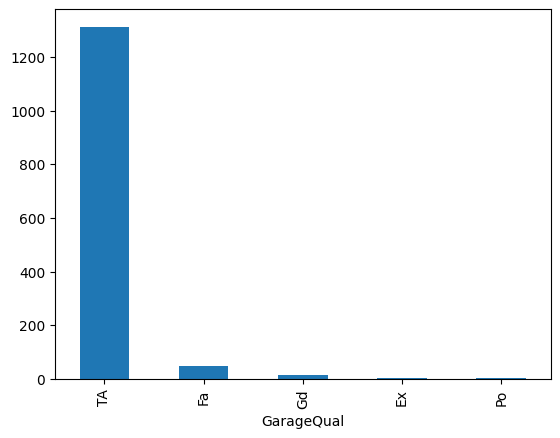

In [91]:
house['GarageQual'].value_counts().plot(kind='bar')

In [92]:
house['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: object

- finding distribtn of 'GarageQual' col

Text(0.5, 1.0, 'GarageQual')

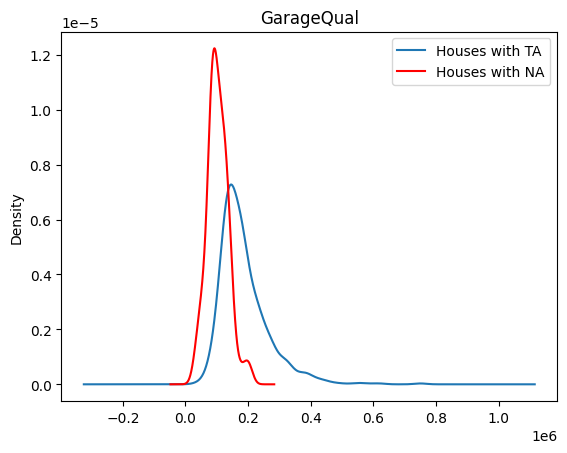

In [93]:
fig = plt.figure()
ax = fig.add_subplot(111)

house[house['GarageQual']=='TA']['SalePrice'].plot(kind='kde', ax=ax)

house[house['GarageQual'].isnull()]['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Houses with TA', 'Houses with NA']
ax.legend(lines, labels, loc='best')

plt.title('GarageQual')

- filling missing val with 'TA' in 'GarageQual' col

In [94]:
temp = house[house['GarageQual']=='TA']['SalePrice']

In [95]:
house['GarageQual'].fillna('TA', inplace=True)

<Axes: xlabel='GarageQual'>

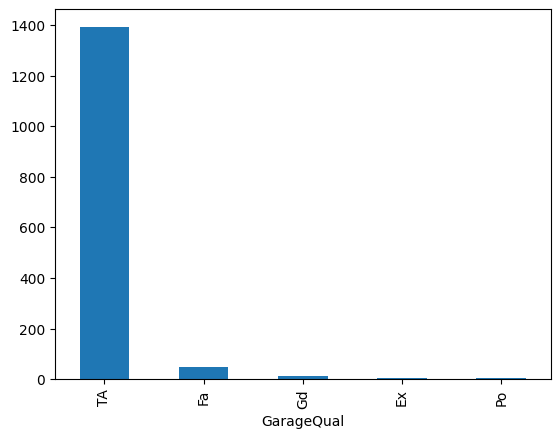

In [96]:
house['GarageQual'].value_counts().plot(kind='bar')

- plotting 'GarageQual' col after Imputatn for distrbtn change

Text(0.5, 1.0, 'GarageQual')

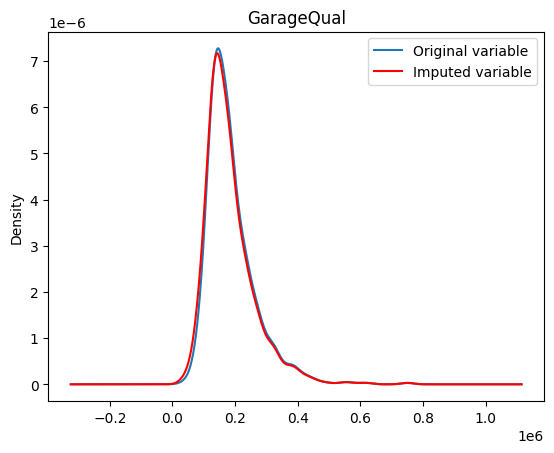

In [97]:
fig = plt.figure()
ax = fig.add_subplot(111)


temp.plot(kind='kde', ax=ax)

# distribution of the variable after imputation
house[house['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Original variable', 'Imputed variable']
ax.legend(lines, labels, loc='best')

# add title
plt.title('GarageQual')

<Axes: xlabel='FireplaceQu'>

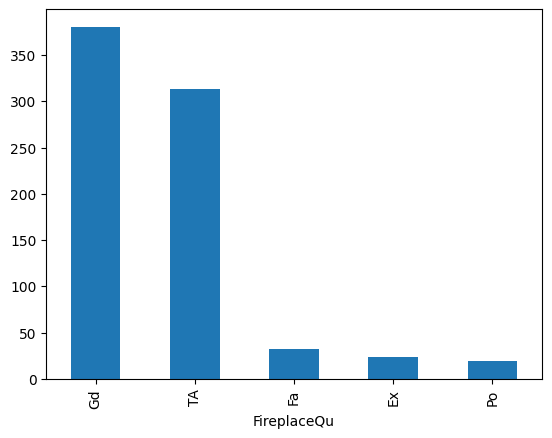

In [98]:
house['FireplaceQu'].value_counts().plot(kind='bar')

In [99]:
house['FireplaceQu'].mode()

0    Gd
Name: FireplaceQu, dtype: object

Text(0.5, 1.0, 'FireplaceQu')

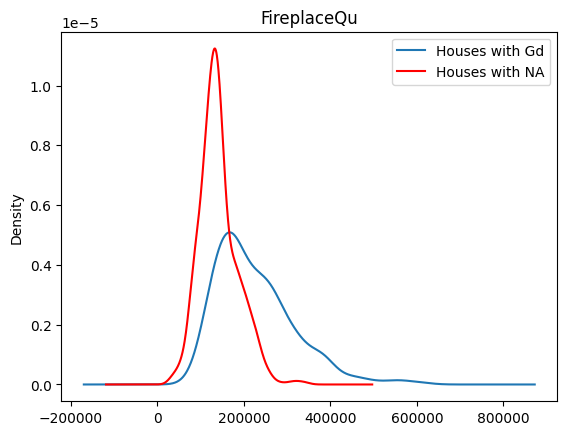

In [100]:
fig = plt.figure()
ax = fig.add_subplot(111)

house[house['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde', ax=ax)

house[house['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Houses with Gd', 'Houses with NA']
ax.legend(lines, labels, loc='best')

plt.title('FireplaceQu')

In [101]:
temp = house[house['FireplaceQu']=='Gd']['SalePrice']

In [102]:
house['FireplaceQu'].fillna('Gd', inplace=True)

<Axes: xlabel='FireplaceQu'>

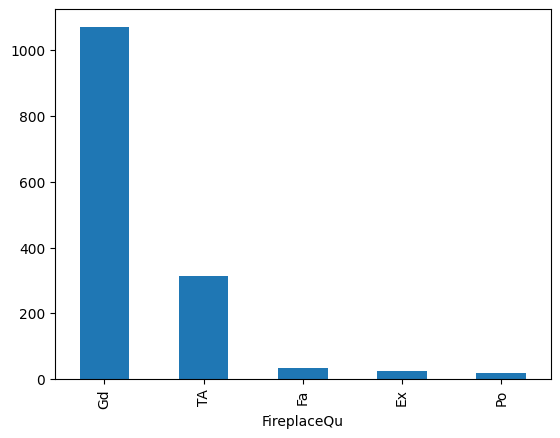

In [103]:
house['FireplaceQu'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'FireplaceQu')

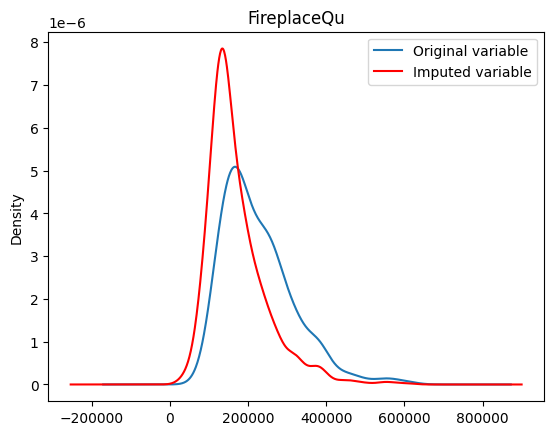

In [104]:
fig = plt.figure()
ax = fig.add_subplot(111)


temp.plot(kind='kde', ax=ax)

# distribution of the variable after imputation
house[house['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Original variable', 'Imputed variable']
ax.legend(lines, labels, loc='best')

# add title
plt.title('FireplaceQu')

- Using sklearn

In [105]:
a = house.iloc[:,0:1]
b = house.iloc[:,-1]

In [106]:
a_tr, a_ts, b_tr, b_ts = train_test_split(a,b,test_size=0.2)

In [107]:
imputer = SimpleImputer(strategy='most_frequent')

In [108]:
a_tr = imputer.fit_transform(a_tr)
a_ts = imputer.transform(a_ts)

In [109]:
imputer.statistics_

array(['Gd'], dtype=object)

> <h4>2. Missing Category Formatn</h4>

a. Using pd
- house['GarageQual'].fillna('Missing', inplace=True)

b. Using sklearn
- imputer = SimpleImputer(strategy='constant', fill_val='Missing')